In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from PIL import Image
from mpl_toolkits.mplot3d import Axes3D
import gudhi
import gudhi.subsampling

SEGMENTATION_DIR = Path("dataset_samples/semantic_segmentation")
N_POINTS = 500
MAX_EDGE_LENGTH = 80  # pixels — limits complex size for tractability


def get_point_cloud(img_path):
    img = np.array(Image.open(img_path).convert("RGB"))
    mask = np.any(img > 10, axis=2)
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return None, None
    pts = np.column_stack([xs, ys]).astype(float)
    colors = img[ys, xs] / 255.0
    return pts, colors


def farthest_point_sample(pts, n):
    if len(pts) <= n:
        return np.arange(len(pts))
    sampled = np.array(gudhi.subsampling.choose_n_farthest_points(points=pts, nb_points=n))
    from scipy.spatial import cKDTree
    _, idx = cKDTree(pts).query(sampled)
    return idx


def compute_persistence(pts):
    rips = gudhi.RipsComplex(points=pts, max_edge_length=MAX_EDGE_LENGTH)
    st = rips.create_simplex_tree(max_dimension=2)
    dgm = st.persistence()
    return dgm


def extract_pairs(dgm, dim):
    return np.array([(b, d) for d_i, (b, d) in dgm if d_i == dim and d != float('inf')])


def draw_vineyard(ax, all_pairs_per_frame, frame_indices, color):
    t_min, t_max = min(frame_indices), max(frame_indices)
    t_norm = [(t - t_min) / (t_max - t_min) if t_max > t_min else 0 for t in frame_indices]
    for pairs, t in zip(all_pairs_per_frame, t_norm):
        if len(pairs):
            ax.scatter(pairs[:, 0], pairs[:, 1], t, c=color, s=20, alpha=0.5, depthshade=False)


def visualize_trial_vineyard(trial_dir):
    frames = sorted(trial_dir.glob("*.png"))
    if not frames:
        return

    label = f"{trial_dir.parent.name}/{trial_dir.name}"
    patient_id = trial_dir.parent.parent.name
    print(f"  Processing {len(frames)} frames for {label}...")

    h0_per_frame, h1_per_frame, frame_indices = [], [], []

    for fpath in frames:
        pts, _ = get_point_cloud(fpath)
        if pts is None:
            continue
        pts_sampled = pts[farthest_point_sample(pts, N_POINTS)]
        dgm = compute_persistence(pts_sampled)
        h0 = extract_pairs(dgm, 0)
        h1 = extract_pairs(dgm, 1)
        h0_per_frame.append(h0 if len(h0) else np.empty((0, 2)))
        h1_per_frame.append(h1 if len(h1) else np.empty((0, 2)))
        frame_indices.append(int(fpath.stem))

    if not frame_indices:
        return

    fig = plt.figure(figsize=(16, 7))
    fig.suptitle(f'Vineyard (Segmentation) - {patient_id} | {label}', fontsize=13, fontweight='bold')

    for subplot_idx, (dim_label, pairs_per_frame, color) in enumerate([
        ('H0 (Components)', h0_per_frame, 'steelblue'),
        ('H1 (Loops)',      h1_per_frame, 'tomato'),
    ]):
        ax = fig.add_subplot(1, 2, subplot_idx + 1, projection='3d')
        draw_vineyard(ax, pairs_per_frame, frame_indices, color)

        all_vals = np.concatenate([p for p in pairs_per_frame if len(p)])
        if len(all_vals):
            vmin, vmax = all_vals.min(), all_vals.max()
            grid = np.linspace(vmin, vmax, 10)
            B, T = np.meshgrid(grid, np.linspace(0, 1, 10))
            ax.plot_surface(B, B, T, alpha=0.07, color='gray')

        ax.set_xlabel("Birth", fontsize=9, labelpad=6)
        ax.set_ylabel("Death", fontsize=9, labelpad=6)
        ax.set_zlabel("Time", fontsize=9, labelpad=6)
        ax.set_title(dim_label, fontsize=11)
        ax.tick_params(labelsize=7)
        ax.view_init(elev=25, azim=-55)

    plt.tight_layout()
    plt.show()
    print(f"  Done: {label}")

  Processing 96 frames for FGS/WJ_1_DensePose...


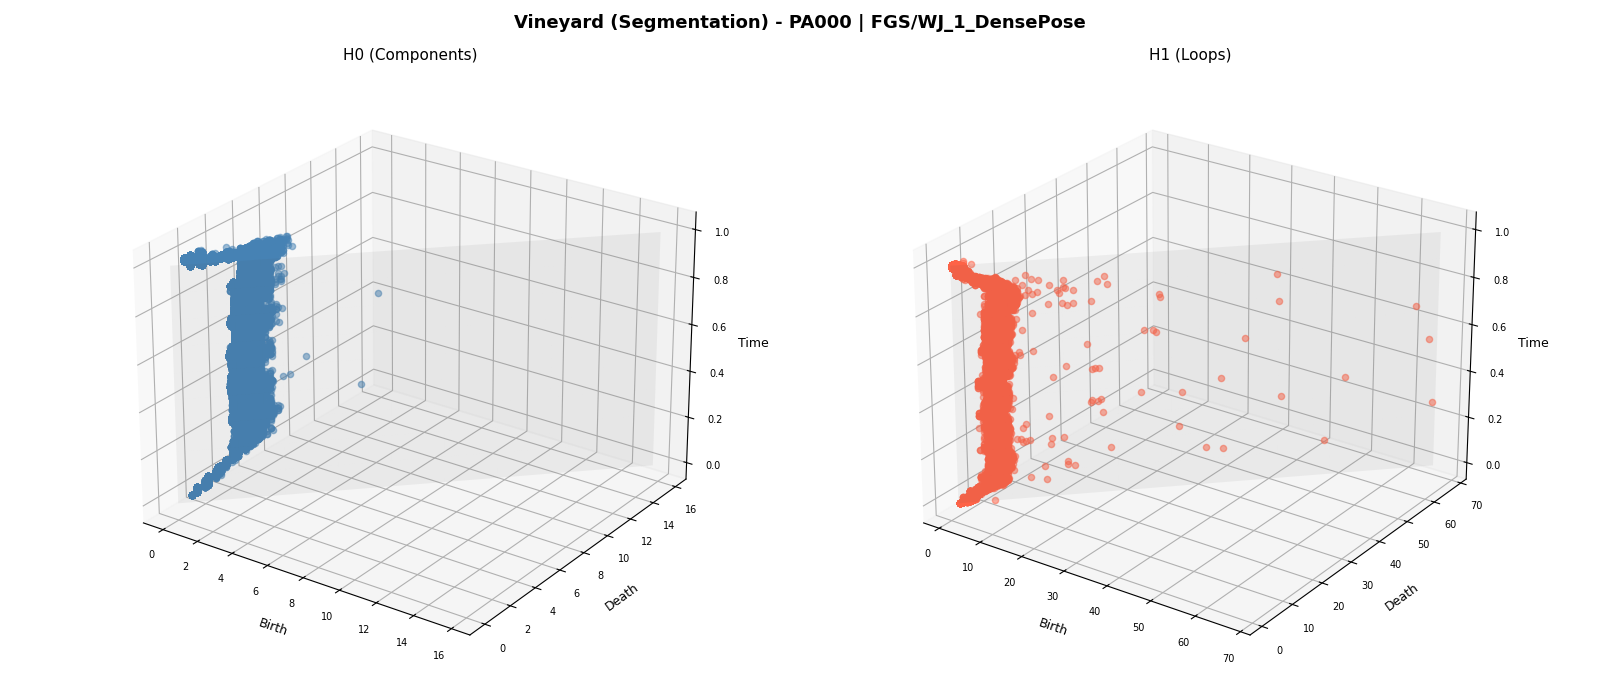

  Done: FGS/WJ_1_DensePose
  Processing 91 frames for FGS/WJ_2_DensePose...


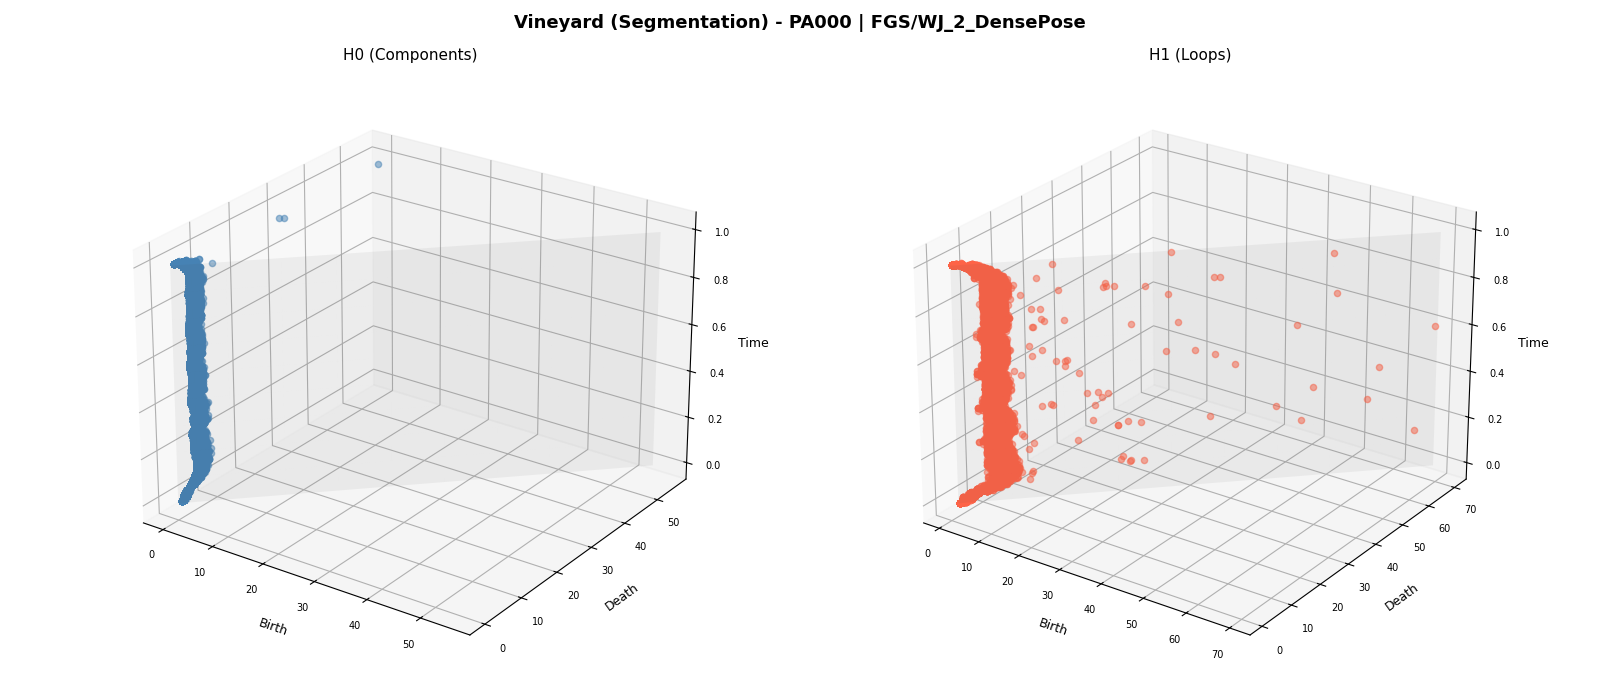

  Done: FGS/WJ_2_DensePose
  Processing 85 frames for FGS/WoJ_1_DensePose...


KeyboardInterrupt: 

In [2]:
for patient_dir in sorted(SEGMENTATION_DIR.iterdir()):
    if not patient_dir.is_dir():
        continue
    for trial_dir in sorted(patient_dir.rglob("*_DensePose")):
        if trial_dir.is_dir():
            visualize_trial_vineyard(trial_dir)